# Neural signal forecasting v9
## time-aware gated axial attention + temporal conv + GCN

## What's New in v9 (Spike-Aware Modeling)
- **Conservative spike awareness:** affi shows occasional upward jumps mid-horizon; v9 adds a light change head to catch these without destabilizing the base value forecast.
- **Fix for mid-horizon jump misses:** v9 explicitly models delta y and up-weights large changes so sudden rises are less likely to be smoothed away.
- **Variance control:** the change loss is weighted with a small lambda, keeping the value head behavior close to v7 while improving jump recall.


In [12]:
# Build dataloader
import torch
import numpy as np
import os
from model_v9 import NFSTNDTModelV9
from utils import *
from trainer import Trainer

input_dir = './'

## What changed in v4
- fix input issue: remove adj from input of forward()

## What's New in v5 Compared to v4
- **New inputs:** optional timestamp tensor `t` with shape `(B, T)` alongside signal `x` (still `(B, T, C, F)`).
- **New modeling assumption:** irregular sampling is allowed; the model uses `delta_t` computed internally from `t`.
- **Architectural change:** time features are encoded (Time2Vec + `delta_t`) and concatenated to signal features *before* the axial attention backbone.
- **Why this helps:** time-awareness reduces the fixed-interval assumption and improves robustness when sampling is uneven or when time context matters.

### Time inputs in this notebook
If your dataset does not include timestamps, we generate a synthetic monotonic `t` using `torch.arange(T)` so the pipeline remains backward compatible. When `delta_t` is constant, v5 behaves like v4 with a richer positional bias.


## Time-aware inputs (v5)
- We construct a timestamp tensor `t` with shape `(B, T)` using `torch.arange(T)` when real timestamps are unavailable.
- The v5 model computes `delta_t = t[:, i] - t[:, i-1]` internally.
- Time2Vec is used inside `model_v5.py` to encode time before the backbone.


In [13]:
# parameters:
# dataset_name = 'beignet'
dataset_name = 'affi'
if dataset_name == 'beignet':
  num_channels = 89
else:
  num_channels = 239

batch_size = 16
num_epochs = 100
learning_rate = 1e-4
hidden_size = 256
n_heads=4
n_layers=3
dropout=0.1
input_size = num_channels

# --- Time-based split (train on past, test on future) ---
# Data is assumed to be ordered in time; we avoid random shuffling here.
raw = np.load(f'dataset/train_data_{dataset_name}.npz')['arr_0']
num_total = len(raw)
train_end = int(num_total * 0.8)
val_end = int(num_total * 0.9)

train_data = raw[:train_end]
val_data = raw[train_end:val_end]
test_data = raw[val_end:]

print(f"Temporal split (indices): train [0:{train_end}), val [{train_end}:{val_end}), test [{val_end}:{num_total})")

Temporal split (indices): train [0:788), val [788:886), test [886:985)


In [14]:
from torch.utils.data import DataLoader
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# Dataset / Dataloader
# ============================================================
train_ds = NeuroForcastDataset(train_data, use_graph=False)
np.savez(
    f'train_data_average_std_{dataset_name}.npz',
    average=train_ds.average,
    std=train_ds.std
)

test_ds = NeuroForcastDataset(
    test_data,
    use_graph=False,
    average=train_ds.average,
    std=train_ds.std
)
val_ds = NeuroForcastDataset(
    val_data,
    use_graph=False,
    average=train_ds.average,
    std=train_ds.std
)

train_data_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_data_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
val_data_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

adj_matrix = compute_adj_matrix(train_data, threshold=0.1).to(torch.device('cuda'))

# ============================================================
# Time handling (unchanged)
# ============================================================
def build_time_tensor(x):
    # x: (B, T, C, F) -> t: (B, T)
    t = torch.arange(x.shape[1], device=x.device, dtype=x.dtype)
    return t.unsqueeze(0).repeat(x.shape[0], 1)

class TimeAwareWrapper(nn.Module):
    """
    Wraps the v9 model so the existing Trainer can call model(x).
    v9 operates on per-channel sequences: (B*C, T, F).
    """
    def __init__(self, base_model, quantiles):
        super().__init__()
        self.base_model = base_model
        self.quantiles = quantiles

    def forward(self, x, t=None):
        # x: (B, T, C, F)
        if t is None:
            t = build_time_tensor(x)

        B, T, C, F = x.shape

        x_flat = x.permute(0, 2, 1, 3).contiguous().view(B * C, T, F)
        t_flat = t.unsqueeze(1).repeat(1, C, 1).view(B * C, T)

        out = self.base_model(x_flat, t_flat)
        y_pred = out["y_pred"]   # (B*C, T, Q)
        dy_pred = out["dy_pred"] # (B*C, T)

        Q = y_pred.shape[-1]
        y_pred = y_pred.view(B, C, T, Q).permute(0, 2, 1, 3).contiguous()
        dy_pred = dy_pred.view(B, C, T).permute(0, 2, 1).contiguous()

        dy_pred = dy_pred.unsqueeze(-1)
        return torch.cat([y_pred, dy_pred], dim=-1)  # (B, T, C, Q+1)

# ============================================================
# Model
# ============================================================
quantiles = [0.1, 0.5, 0.9]

base_model = NFSTNDTModelV9(
    input_size=9,
    hidden_size=hidden_size,
    n_heads=n_heads,
    n_layers=n_layers,
    dropout=dropout,
    num_features=9,
    use_time2vec=True,
    time2vec_k=8,
    use_delta_t=True,
    quantiles=quantiles
).to(torch.device('cuda'))

model = TimeAwareWrapper(base_model, quantiles).to(torch.device('cuda'))

# ============================================================
# Spike threshold (unchanged logic)
# ============================================================
f0 = train_data[..., 0]  # (N,T,C)
dy = f0[:, 1:, :] - f0[:, :-1, :]
abs_dy = np.abs(dy.reshape(-1))
tau = float(np.percentile(abs_dy, 95))
print(f"Spike threshold tau (95th percentile of |delta y|): {tau:.6f}")

spike_weight  = 2.0
lambda_change = 0.2

# ============================================================
# v9.1 Spike-aware + Quantile-consistent loss
# ============================================================
def pinball_loss(y_hat, y, q):
    e = y - y_hat
    return torch.maximum(q * e, (q - 1.0) * e)

def quantile_order_penalty(q10, q50, q90):
    return (
        F.relu(q10 - q50).mean() +
        F.relu(q50 - q90).mean()
    )

change_loss_fn = torch.nn.L1Loss(reduction="none")

def spike_aware_loss_v9_1(pred_tensor, target, init_steps=10):
    """
    pred_tensor: (B, H, C, Q+1)
    target:      (B, H, C)
    """
    Q = len(quantiles)
    y_pred = pred_tensor[..., :Q]   # (B,H,C,Q)
    dy_pred = pred_tensor[..., Q]   # (B,H,C)
    y_true = target                 # (B,H,C)

    # delta y
    dy_true = y_true[:, 1:, :] - y_true[:, :-1, :]
    dy_true = torch.cat([dy_true[:, :1, :], dy_true], dim=1)

    # spike-aware weights
    spike_mask = (torch.abs(dy_true) > tau).float()
    w = 1.0 + spike_mask * (spike_weight - 1.0)

    # -------- quantile losses (q10/q50/q90 ALL trained) --------
    q_losses = []
    for k, q in enumerate(quantiles):
        q_loss = pinball_loss(y_pred[..., k], y_true, q)
        q_losses.append((q_loss * w).mean())
    quant_loss = sum(q_losses) / len(q_losses)

    # -------- ordering penalty (kill quantile crossing) --------
    q10, q50, q90 = y_pred[..., 0], y_pred[..., 1], y_pred[..., 2]
    ord_loss = quantile_order_penalty(q10, q50, q90)

    # -------- delta prediction loss (preserve your design) -----
    change_loss = (change_loss_fn(dy_pred, dy_true) * w).mean()

    # -------- total loss --------------------------------------
    lambda_quant = 1.0
    lambda_ord   = 5.0

    total_loss = (
        lambda_quant * quant_loss +
        lambda_change * change_loss +
        lambda_ord * ord_loss
    )

    return total_loss

# ============================================================
# Optim / Scheduler
# ============================================================
loss_fn = lambda y_hat, y_true: spike_aware_loss_v9_1(y_hat, y_true, init_steps=10)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-2
)

lambda1 = lambda epoch: 0.95 ** (epoch // 20)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda1
)

# ============================================================
# Trainer
# ============================================================
save_path = f'./model_{dataset_name}_v9.pth'

trainer = Trainer(
    model=model,
    train_data_loader=train_data_loader,
    test_data_loader=test_data_loader,
    val_data_loader=val_data_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=torch.device('cuda'),
    scheduler=scheduler,
    forecasting_mode='multi_step',
    init_steps=10,
    save_path=save_path,
    ckpt_path=None,
    max_grad_norm=1.0,
    validate_every=1,
    save_best=True
)

trainer.train(num_epochs)
print("Best val:", trainer.best_val)
print("Best weight path:", save_path)


Spike threshold tau (95th percentile of |delta y|): 256.940000


Epoch 1/100: 100%|██████████| 50/50 [00:02<00:00, 17.82it/s, train_loss=0.237913, lr=3.00e-04]


Epoch 000 | lr=3.000000e-04 | Train=0.237913 | Val=0.067898
[BEST] Saved to ./model_affi_v9.pth | best_val=0.067898


Epoch 2/100: 100%|██████████| 50/50 [00:02<00:00, 19.13it/s, train_loss=0.084193, lr=3.00e-04]


Epoch 001 | lr=3.000000e-04 | Train=0.082509 | Val=0.076050


...

Epoch 097 | lr=2.443519e-04 | Train=0.036596 | Val=0.040605


Epoch 99/100: 100%|██████████| 50/50 [00:02<00:00, 19.71it/s, train_loss=0.037360, lr=2.44e-04]


Epoch 098 | lr=2.443519e-04 | Train=0.036613 | Val=0.041213


Epoch 100/100: 100%|██████████| 50/50 [00:02<00:00, 19.78it/s, train_loss=0.036931, lr=2.44e-04]
                                                             

Epoch 099 | lr=2.321343e-04 | Train=0.036192 | Val=0.039964
Best val: 0.03923760620611055
Best weight path: ./model_affi_v9.pth


## What's New in v6 Compared to v5
- **Why point forecasting is insufficient:** v5 produces a single trajectory, but real neural signals are noisy and multi-modal; a single point hides ambiguity and can be overconfident when the test distribution shifts.
- **What uncertainty means here:** for each future time and channel, multiple plausible outcomes exist due to measurement noise and changing dynamics.
- **How v6 models predictive uncertainty:** v6 predicts multiple **quantiles** of the target distribution (e.g., 0.1, 0.5, 0.9) using a pinball loss. This yields a median forecast plus uncertainty bands.
- **Why this improves robustness under distribution shift:** quantile outputs avoid overconfident point estimates and provide calibrated ranges that remain useful even when patterns differ from training.

## Output shape (v6)
- Model output: `y_hat` has shape `(B, T, C, Q)` where `Q = len(quantiles)`.
- For multi-step forecasting, the trainer compares `y_hat[:, init_steps:, :, :]` against target `(B, H, C)`.

## What's New in v7 Compared to v6
- **Why autoregressive forecasting is problematic:** rolling predictions forward compounds errors and can drift quickly when the data distribution shifts.
- **How direct multi-horizon prediction improves stability:** v7 predicts the entire future window in a single forward pass, avoiding step-by-step error accumulation.
- **Why time-based evaluation is necessary:** random splits leak future patterns into training; strict temporal splits better match real deployment.
- **How v7 better measures generalization:** per-horizon metrics and interval coverage expose where the model degrades as the horizon grows.

## Direct multi-horizon forecasting (v7)
- Forecast horizon `H = T - init_steps` is predicted directly in one pass (no autoregressive rollout).
- Model output for evaluation: `y_hat_future` has shape `(B, H, C, Q)`.
- **Backward compatibility:** when `H = 1` and horizon weights are uniform, v7 reduces to the v6 objective.

## Temporal evaluation protocol (v7)
- **Train:** earliest 80% of samples
- **Val:** next 10%
- **Test:** final 10% (most recent)
- This mirrors real-world deployment where only past data is available for training.

## Spike-aware loss (v9)
- Compute delta y on the target feature and mark spikes where |delta y| > tau.
- tau is estimated from training data (high-percentile of |delta y|), so thresholds are data-driven.
- Spike horizons receive an extra loss weight to prioritize rare jumps.


Per-horizon MSE (median): [0.004234 0.008805 0.012408 0.01522  0.017337 0.01902  0.019733 0.017391
 0.016743 0.016903]
Per-horizon MAE (median): [0.049523 0.071437 0.083779 0.094498 0.099562 0.105261 0.107404 0.099988
 0.097558 0.099262]
Per-horizon 80% interval coverage (q10-q90): [0.862 0.829 0.819 0.791 0.785 0.761 0.759 0.801 0.809 0.8  ]
Per-horizon spike recall (upward jumps): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


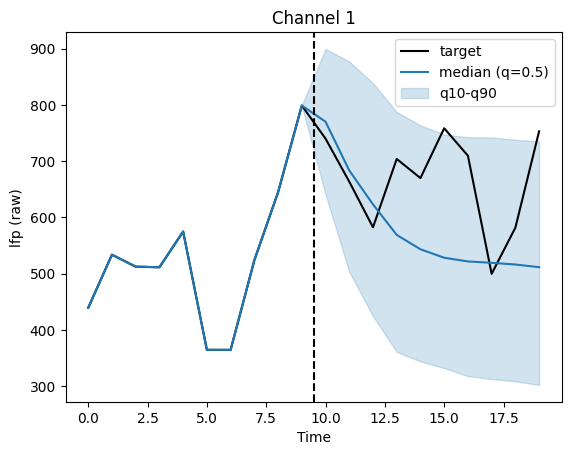

In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt

INIT_STEPS = 10
DEVICE = torch.device("cuda")

# --- Load BEST model ---
quantiles = [0.1, 0.5, 0.9]
base_model_test = NFSTNDTModelV9(
    input_size=9,
    hidden_size=hidden_size,
    n_heads=n_heads,
    n_layers=n_layers,
    dropout=dropout,
    num_features=9,
    use_time2vec=True,
    time2vec_k=8,
    use_delta_t=True,
    quantiles=quantiles
).to(DEVICE)
model_test = TimeAwareWrapper(base_model_test, quantiles).to(DEVICE)
model_test.load_state_dict(torch.load(f'./model_{dataset_name}_v9.pth', map_location="cpu"))
model_test.eval()

# --- De-normalization helpers (feature 0 only) ---
stats = np.load(f'train_data_average_std_{dataset_name}.npz')
avg_cf = stats['average']  # (1, C*F)
std_cf = stats['std']
num_feats = avg_cf.shape[1] // num_channels
avg_f0 = avg_cf.reshape(1, num_channels, num_feats)[..., 0]
std_f0 = std_cf.reshape(1, num_channels, num_feats)[..., 0]
combine_max = avg_f0 + 4 * std_f0
combine_min = avg_f0 - 4 * std_f0

def denorm_feature0(x, channel_idx=None):
    x_np = x.detach().cpu().numpy() if torch.is_tensor(x) else x
    if x_np.shape[-1] == num_channels:
        return ((x_np + 1) / 2) * (combine_max - combine_min) + combine_min
    if channel_idx is None:
        raise ValueError("channel_idx required for single-channel inputs")
    cmax = combine_max[..., channel_idx]
    cmin = combine_min[..., channel_idx]
    return ((x_np + 1) / 2) * (cmax - cmin) + cmin

def prepare_input_masked(data, init_steps=INIT_STEPS):
    # data: (B,20,C,F)
    future = data.shape[1] - init_steps
    x_in = torch.cat([
        data[:, :init_steps, :, :],
        data[:, init_steps-1:init_steps, :, :].repeat(1, future, 1, 1)
    ], dim=1)
    y_future = data[:, init_steps:, :, 0]  # (B,10,C) feature0 target
    return x_in, y_future

@torch.no_grad()
def eval_metrics_per_horizon(model, loader, device=DEVICE, init_steps=INIT_STEPS, spike_tau=0.0):
    preds_q, preds_dy, tgts = [], [], []
    for batch in loader:
        batch = batch.to(device)  # (B,20,C,F)
        x_in, y_future = prepare_input_masked(batch, init_steps=init_steps)
        t_in = build_time_tensor(x_in)

        out = model(x_in, t_in)  # (B,20,C,Q+1)
        Q = len(quantiles)
        y_hat_full = out[..., :Q]
        dy_hat_full = out[..., Q]

        y_hat_future = y_hat_full[:, init_steps:, :, :]  # (B,H,C,Q)
        dy_hat_future = dy_hat_full[:, init_steps:, :]   # (B,H,C)

        preds_q.append(y_hat_future.detach().cpu())
        preds_dy.append(dy_hat_future.detach().cpu())
        tgts.append(y_future.detach().cpu())

    preds_q = torch.cat(preds_q, dim=0)
    preds_dy = torch.cat(preds_dy, dim=0)
    tgts = torch.cat(tgts, dim=0)

    q10 = preds_q[..., quantiles.index(0.1)]
    q50 = preds_q[..., quantiles.index(0.5)]
    q90 = preds_q[..., quantiles.index(0.9)]

    mse_h = torch.mean((tgts - q50) ** 2, dim=(0, 2)).numpy()
    mae_h = torch.mean(torch.abs(tgts - q50), dim=(0, 2)).numpy()
    coverage_h = torch.mean(((tgts >= q10) & (tgts <= q90)).float(), dim=(0, 2)).numpy()

    # Spike recall: upward jumps only
    dy_true = tgts[:, 1:, :] - tgts[:, :-1, :]
    dy_true = torch.cat([dy_true[:, :1, :], dy_true], dim=1)
    spike_true = dy_true > spike_tau
    spike_pred = preds_dy > spike_tau
    spike_recall_h = torch.mean((spike_pred & spike_true).float() / (spike_true.float() + 1e-6), dim=(0, 2)).numpy()

    return mse_h, mae_h, coverage_h, spike_recall_h, preds_q.numpy(), tgts.numpy()

# reuse tau from training stats
f0 = train_data[..., 0]
dy = f0[:, 1:, :] - f0[:, :-1, :]
abs_dy = np.abs(dy.reshape(-1))
tau = float(np.percentile(abs_dy, 95))

mse_h, mae_h, cov_h, spike_recall_h, pred_future_q, tgt_future = eval_metrics_per_horizon(
    model_test, test_data_loader, DEVICE, INIT_STEPS, spike_tau=tau
)
print("Per-horizon MSE (median):", np.round(mse_h, 6))
print("Per-horizon MAE (median):", np.round(mae_h, 6))
print("Per-horizon 80% interval coverage (q10-q90):", np.round(cov_h, 3))
print("Per-horizon spike recall (upward jumps):", np.round(spike_recall_h, 3))

# --- Plot one example (full 20 steps) with uncertainty band ---

@torch.no_grad()
def plot_channel_quantiles(model, data_loader, channel_idx=1, device=torch.device("cuda"), init_steps=10, denorm=True):
    model.eval()
    batch = next(iter(data_loader)).to(device)   # (B,20,C,F)

    # build masked input
    future = batch.shape[1] - init_steps
    x_in = torch.cat([
        batch[:, :init_steps, :, :],
        batch[:, init_steps-1:init_steps, :, :].repeat(1, future, 1, 1)
    ], dim=1)

    # model output
    t_in = build_time_tensor(x_in)
    out = model(x_in, t_in)  # (B,20,C,Q+1)
    Q = len(quantiles)
    y_hat_q = out[..., :Q]

    # enforce competition rule: first 10 steps are given
    y_hat_q[:, :init_steps, :, :] = batch[:, :init_steps, :, 0].unsqueeze(-1)

    # pick one sample
    y_true = batch[0, :, channel_idx, 0]
    y_q10 = y_hat_q[0, :, channel_idx, quantiles.index(0.1)]
    y_q50 = y_hat_q[0, :, channel_idx, quantiles.index(0.5)]
    y_q90 = y_hat_q[0, :, channel_idx, quantiles.index(0.9)]

    if denorm:
        y_true = denorm_feature0(y_true, channel_idx=channel_idx)
        y_q10 = denorm_feature0(y_q10, channel_idx=channel_idx)
        y_q50 = denorm_feature0(y_q50, channel_idx=channel_idx)
        y_q90 = denorm_feature0(y_q90, channel_idx=channel_idx)
        ylabel = "lfp (raw)"
    else:
        y_true = y_true.detach().cpu().numpy()
        y_q10 = y_q10.detach().cpu().numpy()
        y_q50 = y_q50.detach().cpu().numpy()
        y_q90 = y_q90.detach().cpu().numpy()
        ylabel = "lfp (normalized)"

    assert np.all(y_q10 <= y_q50), "Quantile violation: q10 > q50"
    assert np.all(y_q50 <= y_q90), "Quantile violation: q50 > q90"


    plt.figure()
    plt.plot(y_true, label="target", color="black")
    plt.plot(y_q50, label="median (q=0.5)", color="tab:blue")
    plt.fill_between(np.arange(len(y_q50)), y_q10, y_q90, color="tab:blue", alpha=0.2, label="q10-q90")
    plt.axvline(x=init_steps-0.5, color="black", linestyle="--")
    plt.title(f"Channel {channel_idx}")
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()


plot_channel_quantiles(model_test, test_data_loader, channel_idx=1)
